In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
.. _uoi_lasso:

UoI-Lasso for sparse, minimal bias, regression
=============================r[i================

This example with demonstrate the ability of UoI-Lasso to recover sparse
models with minimal bias.

"""

###############################################################################
# Load synthetic data
# -------------------
#
# The synthetic data will have 40 features, 10 of which are informative and
# 1 response variable.

import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
from var_utils import *
from tqdm import tqdm

ModuleNotFoundError: No module named 'pandas'

In [ ]:
X = np.load("/global/cfs/cdirs/m2043/causal_inference/dale-gen-sim-may27/input_uoi/Xt_daleM20may27_simu.npy")

(array([   96.,   861.,  4796., 15252., 26232., 25179., 13233.,  3732.,
          569.,    50.]),
 array([-1.03027344, -0.8203125 , -0.61083984, -0.40136719, -0.19140625,
         0.01855469,  0.22753906,  0.4375    ,  0.64746094,  0.85742188,
         1.06640625]),
 <BarContainer object of 10 artists>)

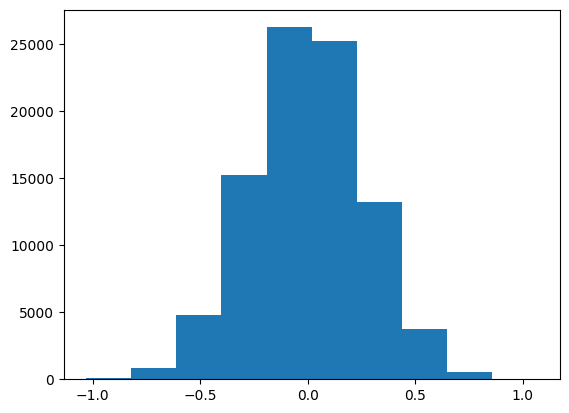

In [10]:
plt.hist(X[:,1])

In [ ]:
from pyuoi.linear_model import UoI_Poisson

### Gaussian VAR model

In [56]:
n_features = 10
n_samples = 15
lag = 2


data, transition_matrices, cov = generate_sparse_stationary_var_process(
    n_features,
    n_samples,
    lag=lag,
    sparsity=0.5,
    spectral_radius=0.6,  # Ensures stationarity
    process_type='gaussian'

)

In [ ]:
uoi_var = UoI_Lasso(n_real_features = n_features, fit_VAR = True, fit_intercept = False, random_state=42)
uoi_var.fit(data)
B_model = uoi_var.VAR_coef_

In [ ]:
# OBSOLETE: construct the lagged connectivity matrices from the model coefficient
A_model = [B_model.reshape(n_features,n_features*lag).T[i*n_features:(i+1)*n_features].T for i in range(lag)]

In [ ]:
# prediction
yhat = uoi_var.predict(X)

# converted back to time series array
true_response = Y.reshape((n_samples-lag,n_features),order = "F")  #shape: each row is a sample of length n_features
prediction = yhat.reshape((n_samples-lag,n_features),order = "F")

Text(0, 0.5, 'relative error between y_hat and y')

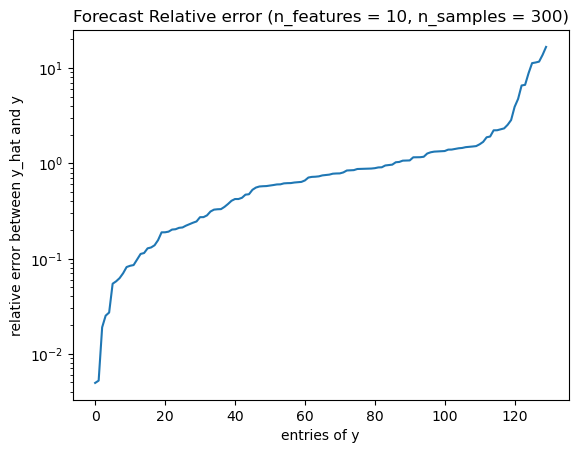

In [73]:
plt.plot(np.sort(np.abs((yhat - Y)/Y)))
plt.yscale("log")
plt.title("Prediction Relative error")
plt.xlabel("entries of y")
plt.ylabel("relative error between y_hat and y")

### Poisson VAR model

In [12]:
# Example usage
n_features = 10
n_samples = 10
lag = 1


base_intensity = np.random.randint(1, 10, n_features).astype(np.float64)  # Base rates for each feature

data, transition_matrices, _ = generate_sparse_stationary_var_process(
    n_features,
    n_samples,
    lag=lag,
    sparsity=0.5,
    quench_factor = 1, 
    spectral_radius=0.9,  # Ensures stationarity
    process_type='poisson',
    base_intensity=base_intensity

)

In [ ]:
# have to set fit_intercept = False since the curretn VAR implementation doesn consider constant model terms
poisson = UoI_Poisson(n_real_features = n_features, fit_VAR =True, max_iter=2500, fit_intercept=False, random_state=42)

poisson.fit(data)

In [15]:
B_model = poisson.VAR_coef_
#B_truth = np.vstack([m.toarray().T for m in transition_matrices]).T.flatten()
selection_accuracy(B_truth, B_model)

0.21311475409836067